In [1]:
import yfinance as yf
import pandas as pd

# Define the tickers and the time period
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-07-01'
end_date = '2025-07-31'

# Download historical data
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False)

# Extract individual dataframes
tsla_df = data['TSLA'].copy()
bnd_df = data['BND'].copy()
spy_df = data['SPY'].copy()

# Optional: Reset index to have 'Date' as a column
tsla_df.reset_index(inplace=True)
bnd_df.reset_index(inplace=True)
spy_df.reset_index(inplace=True)


[*********************100%***********************]  3 of 3 completed


In [30]:
print(tsla_df.head())
print(bnd_df.head())
print(spy_df.head())


Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-07-01  18.073999  18.174667  17.856667  17.943333  17.943333   
1     2015-07-02  18.680000  18.830000  18.220667  18.667999  18.667999   
2     2015-07-06  18.591999  18.779333  18.420000  18.648001  18.648001   
3     2015-07-07  18.333332  18.346666  17.384666  17.858667  17.858667   
4     2015-07-08  17.288000  17.386667  16.954000  16.997334  16.997334   

Price     Volume  
0       31518000  
1      107458500  
2       61828500  
3       91576500  
4       93316500  
Price       Date       Open       High        Low      Close  Adj Close  \
0     2015-07-01  80.870003  81.029999  80.830002  80.900002  60.816727   
1     2015-07-02  81.059998  81.180000  81.059998  81.099998  60.967075   
2     2015-07-06  81.440002  81.440002  81.220001  81.379997  61.177551   
3     2015-07-07  81.690002  81.769997  81.459999  81.459999  61.237728   
4     2015-07-08  81.639999  81.760002  81.559998  81.690002

In [31]:
tsla_df.to_csv("../data/TSLA_data.csv", index=False)
bnd_df.to_csv("../data/BND_data.csv", index=False)
spy_df.to_csv("../data/SPY_data.csv", index=False)


In [32]:
# Check data types and non-null counts
tsla_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2535 non-null   datetime64[ns]
 1   Open       2535 non-null   float64       
 2   High       2535 non-null   float64       
 3   Low        2535 non-null   float64       
 4   Close      2535 non-null   float64       
 5   Adj Close  2535 non-null   float64       
 6   Volume     2535 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 138.8 KB


In [2]:
# Summary statistics
tsla_df.describe()
# Count missing values
tsla_df.isnull().sum()



Price
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

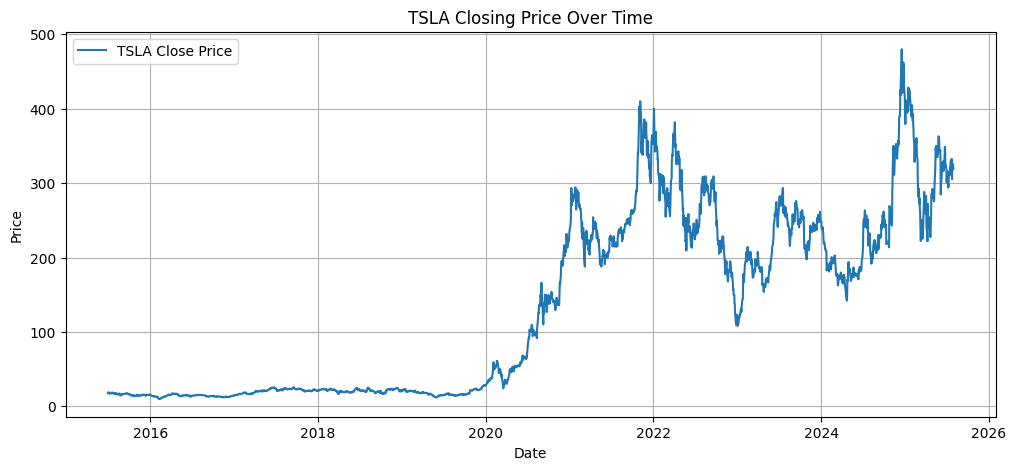

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(tsla_df['Date'], tsla_df['Close'], label='TSLA Close Price')
plt.title('TSLA Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


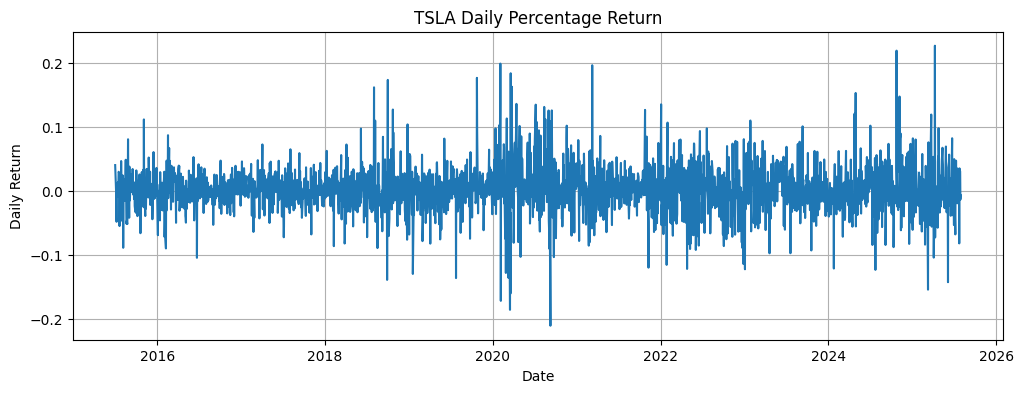

In [4]:
tsla_df['Daily Return'] = tsla_df['Close'].pct_change()

plt.figure(figsize=(12, 4))
plt.plot(tsla_df['Date'], tsla_df['Daily Return'], label='TSLA Daily Return')
plt.title('TSLA Daily Percentage Return')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()


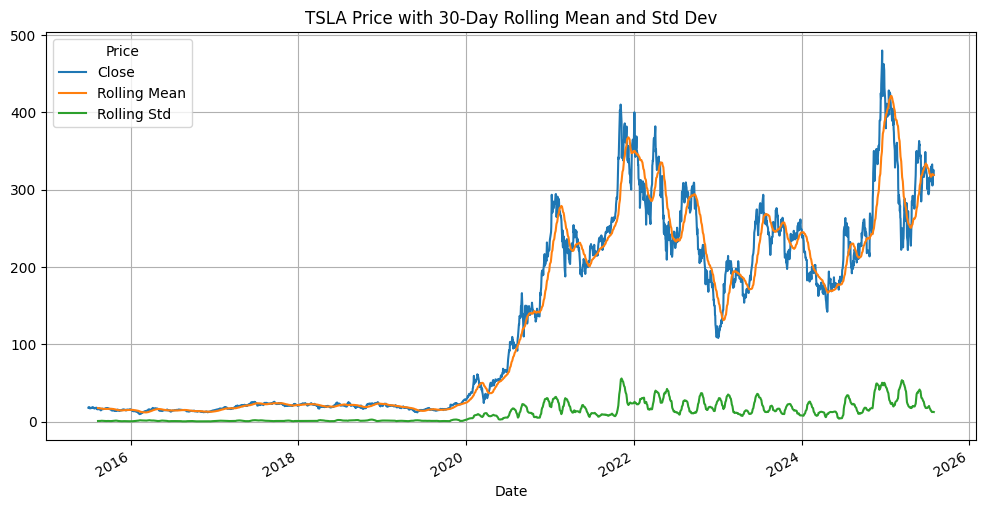

In [5]:
tsla_df['Rolling Mean'] = tsla_df['Close'].rolling(window=30).mean()
tsla_df['Rolling Std'] = tsla_df['Close'].rolling(window=30).std()

tsla_df[['Date', 'Close', 'Rolling Mean', 'Rolling Std']].set_index('Date').plot(figsize=(12, 6))
plt.title('TSLA Price with 30-Day Rolling Mean and Std Dev')
plt.grid(True)
plt.show()


In [6]:
from scipy.stats import zscore

# Create a new column initialized with NaNs
tsla_df['Z-Score'] = float('nan')

# Compute z-scores only on non-NaN Daily Returns and assign back properly
tsla_df.loc[tsla_df['Daily Return'].notna(), 'Z-Score'] = zscore(tsla_df['Daily Return'].dropna())

# Identify outliers: z-score > 3 or < -3
outliers = tsla_df[(tsla_df['Z-Score'] > 3) | (tsla_df['Z-Score'] < -3)]

# Print outlier days
print("Outlier Days (Z-Score > 3 or < -3):")
print(outliers[['Date', 'Daily Return', 'Z-Score']])


Outlier Days (Z-Score > 3 or < -3):
Price       Date  Daily Return   Z-Score
778   2018-08-02      0.161880  4.293466
818   2018-09-28     -0.139015 -3.778190
819   2018-10-01      0.173471  4.604406
835   2018-10-23      0.127189  3.362862
894   2019-01-18     -0.129711 -3.528600
1023  2019-07-25     -0.136137 -3.700979
1087  2019-10-24      0.176692  4.690810
1155  2020-02-03      0.198949  5.287844
1156  2020-02-04      0.137256  3.632924
1157  2020-02-05     -0.171758 -4.656536
1172  2020-02-27     -0.128146 -3.486610
1179  2020-03-09     -0.135725 -3.689931
1182  2020-03-12     -0.116172 -3.165418
1184  2020-03-16     -0.185778 -5.032620
1186  2020-03-18     -0.160344 -4.350341
1187  2020-03-19      0.183877  4.883538
1190  2020-03-24      0.162817  4.318611
1203  2020-04-13      0.136038  3.600250
1261  2020-07-06      0.134794  3.566867
1288  2020-08-12      0.131236  3.471434
1301  2020-08-31      0.125689  3.322625
1306  2020-09-08     -0.210628 -5.699237
1310  2020-09-14     

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(tsla_df['Close'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -1.4188720053968273
p-value: 0.5731959514207222


c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2140
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6816.645
Date:                Sat, 09 Aug 2025   AIC                          13645.290
Time:                        09:45:57   BIC                          13679.298
Sample:                             0   HQIC                         13657.735
                               - 2140                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0280      0.013     -2.146      0.032      -0.053      -0.002
ar.L2          0.0128      0.011      1.128      0.259      -0.009       0.035
ar.L3         -0.0077      0.014     -0.533      0.5

c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\KIDIST\Documents\Time-series-forcasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


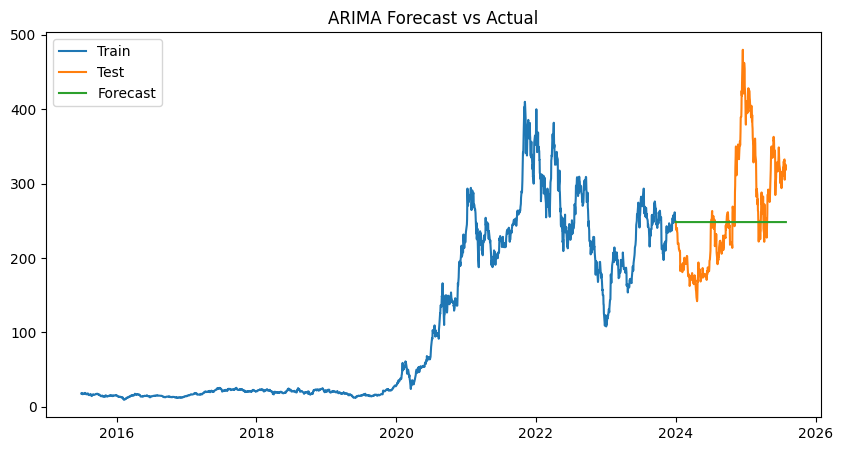

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load data
df = pd.read_csv("../data/TSLA_data.csv", parse_dates=['Date'], index_col='Date')
tsla_close = df['Close']
train = tsla_close[:'2023']
test = tsla_close['2024':]

# Optional: visualize ACF/PACF to help select order
# plot_acf(train); plot_pacf(train); plt.show()

# Manually specify the ARIMA order based on ACF/PACF or trial-and-error
order = (5, 1, 0)  # You can experiment with (p,d,q)

# Fit ARIMA model
model = ARIMA(train, order=order)
model_fit = model.fit()

# Summary
print(model_fit.summary())

# Forecast
forecast_arima = model_fit.forecast(steps=len(test))

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_arima, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

df = pd.read_csv("../data/TSLA_data.csv", parse_dates=['Date'], index_col='Date')
df = df[['Close']]  # Use 'Close' price for forecasting
df.dropna(inplace=True)

train = df[:'2023']
test = df['2024':]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


def create_sequences(data, seq_length=60):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60  # 60 previous days to predict next day

X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Reshape for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

predictions = model.predict(X_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))
plt.figure(figsize=(12,6))
plt.plot(test.index[seq_length:], y_test_unscaled, label="Actual")
plt.plot(test.index[seq_length:], predictions_unscaled, label="Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("LSTM Forecast vs Actual (Tesla)")
plt.legend()
plt.grid(True)
plt.show()


mae = mean_absolute_error(y_test_unscaled, predictions_unscaled)
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape * 100:.2f}%")



ModuleNotFoundError: No module named 'tensorflow'